In [6]:
import os
import json
import cv2
import torch
import networkx as nx
import pandas as pd
import numpy as np

from tqdm import tqdm

import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

from PIL import Image

In [7]:
import sys
import os

sys.path.append(
    os.path.abspath("..")
)

In [8]:
from src.models.hybrid_model import HybridComposeNet

In [9]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = HybridComposeNet().to(device)

model.load_state_dict(

    torch.load(
        "../checkpoints/hybrid_compose_net.pth",
        map_location=device
    )
)

model.eval()

HybridComposeNet(
  (cnn): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, trac

In [10]:
def extract_embedding(self, data):

    # IMAGE BRANCH

    
    images = data.image.view(-1, 3, 224, 224)

    cnn_features = self.cnn(images)

    # GRAPH BRANCH

    x = data.x

    edge_index = data.edge_index

    batch = data.batch

    x = self.conv1(x, edge_index)

    x = F.relu(x)

    x = self.conv2(x, edge_index)

    x = F.relu(x)

    graph_features = global_mean_pool(
        x,
        batch
    )

    # FUSION

    combined = torch.cat(

        [cnn_features, graph_features],

        dim=1
    )

    embedding = self.fc1(combined)

    return embedding

In [11]:
embeddings = []

image_names = []

In [12]:
import pandas as pd
dataset_df = pd.read_csv(
    "../data/processed/full_composition_dataset.csv"
)

IMAGE_DIR = "../data/raw/CADB/images"

In [13]:
import torchvision.transforms as transforms

transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485, 0.456, 0.406],

        std=[0.229, 0.224, 0.225]

    )
])

In [14]:
def create_hybrid_sample(

    image_path,
    graph_path,
    target

):

    img = cv2.imread(image_path)

    if img is None:
        return None

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    image_tensor = transform(img)

    with open(graph_path, "r") as f:

        graph_data = json.load(f)

    G = nx.node_link_graph(graph_data)

    node_features = []

    for node, attrs in G.nodes(data=True):

        feature_vector = [

            attrs["center_x"],
            attrs["center_y"],
            attrs["area"],
            attrs["confidence"]

        ]

        node_features.append(feature_vector)

    if len(node_features) == 0:

        return None

    x = torch.tensor(
        node_features,
        dtype=torch.float
    )

    edge_index = []

    for u, v in G.edges():

        edge_index.append([u,v])
        edge_index.append([v,u])

    if len(edge_index) == 0:

        edge_index = [[0,0]]

    edge_index = torch.tensor(
        edge_index,
        dtype=torch.long
    ).t().contiguous()

    data = Data(

        x=x,

        edge_index=edge_index,

        y=torch.tensor(
            [target],
            dtype=torch.float
        )
    )

    data.image = image_tensor

    # IMPORTANT
    data.image_name = os.path.basename(image_path)

    return data

In [15]:
hybrid_dataset = []

In [16]:
subset = dataset_df

In [17]:
from torch_geometric.data import Data

In [18]:
for idx, row in tqdm(subset.iterrows()):

    image_name = row["image_name"]

    image_path = os.path.join(
        IMAGE_DIR,
        image_name
    )

    graph_path = (
        "../data/processed/graphs/"
        + image_name
        + ".json"
    )

    if not os.path.exists(graph_path):
        continue

    try:

        target = row["edge_density"]

        sample = create_hybrid_sample(

            image_path,
            graph_path,
            target

        )

        if sample is not None:

            hybrid_dataset.append(sample)

    except Exception as e:

        print(image_name, e)

9497it [02:58, 53.22it/s]


In [19]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(

    hybrid_dataset,

    test_size=0.2,

    random_state=42
)

In [20]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(

    train_data,

    batch_size=8,

    shuffle=True
)

test_loader = DataLoader(

    test_data,

    batch_size=8
)

In [21]:
with torch.no_grad():

    for batch in test_loader:

        batch = batch.to(device)

        emb = model.extract_embedding(batch)

        emb = emb.cpu().numpy()

        embeddings.extend(emb)

In [22]:
embeddings = np.array(embeddings)

print(embeddings.shape)

(1493, 128)


In [23]:
tsne = TSNE(

    n_components=2,

    perplexity=30,

    random_state=42
)

embedding_2d = tsne.fit_transform(
    embeddings
)

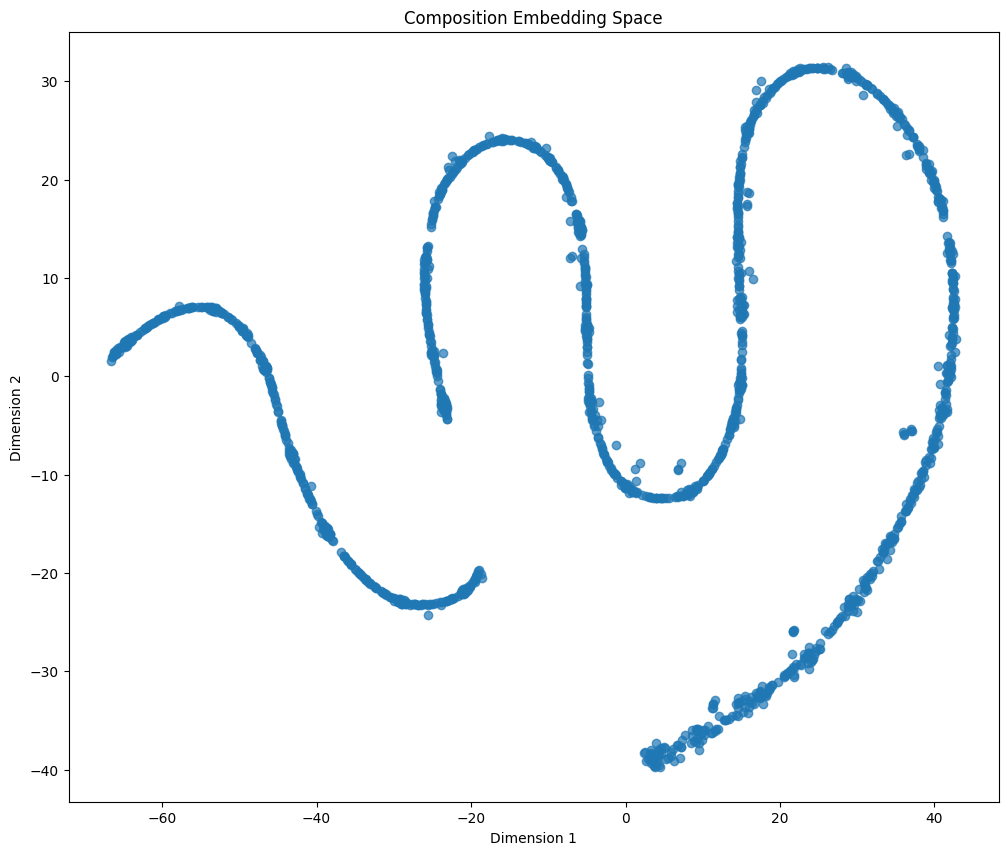

In [24]:
plt.figure(figsize=(12,10))

plt.scatter(

    embedding_2d[:,0],

    embedding_2d[:,1],

    alpha=0.7
)

plt.title(
    "Composition Embedding Space"
)

plt.xlabel("Dimension 1")

plt.ylabel("Dimension 2")

plt.show()

In [25]:
kmeans = KMeans(

    n_clusters=5,

    random_state=42
)

clusters = kmeans.fit_predict(
    embeddings
)

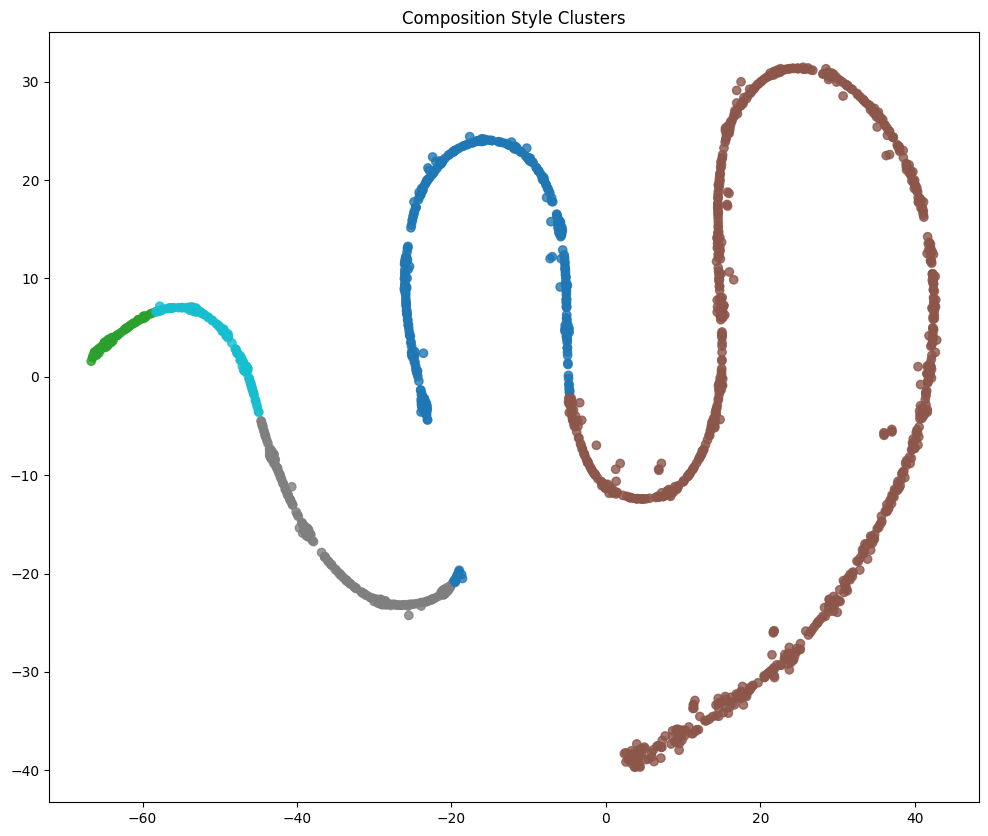

In [26]:
plt.figure(figsize=(12,10))

plt.scatter(

    embedding_2d[:,0],

    embedding_2d[:,1],

    c=clusters,

    cmap="tab10",

    alpha=0.8
)

plt.title(
    "Composition Style Clusters"
)

plt.show()

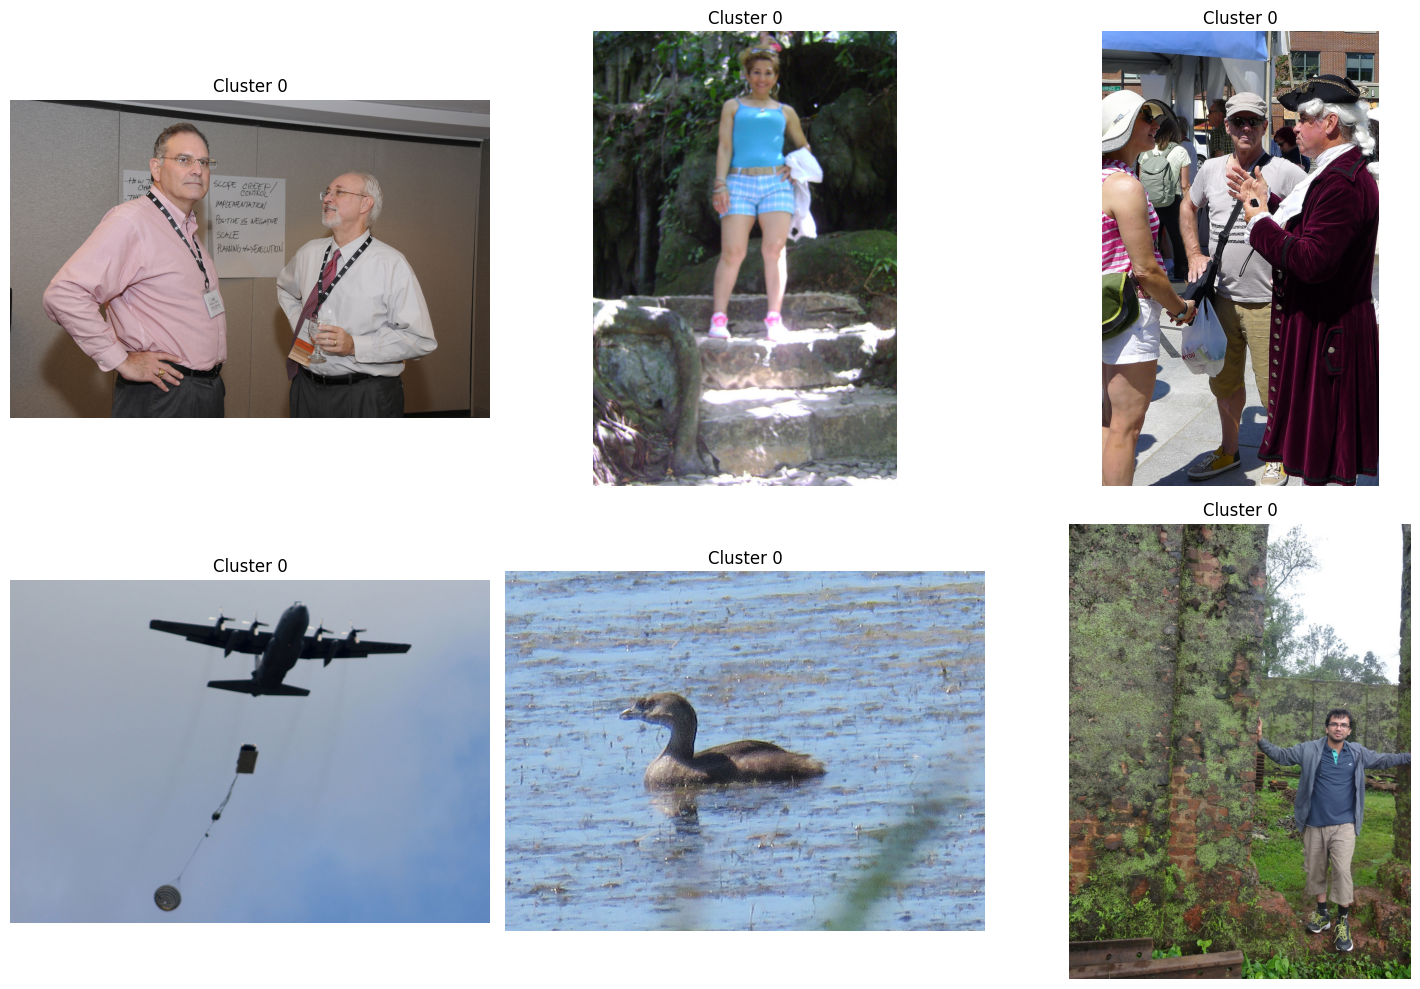

In [30]:
cluster_id = 0

indices = np.where(clusters == cluster_id)[0][:6]

plt.figure(figsize=(15,10))

for i, idx in enumerate(indices):

    image_name = test_data[idx].image_name

    image_path = os.path.join(
        IMAGE_DIR,
        image_name
    )

    img = cv2.imread(image_path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(2,3,i+1)

    plt.imshow(img)

    plt.title(f"Cluster {cluster_id}")

    plt.axis("off")

plt.tight_layout()

plt.show()

In [31]:
from sklearn.metrics.pairwise import cosine_similarity
query_idx = 0
similarities = cosine_similarity(

    [embeddings[query_idx]],

    embeddings
)[0]
top_indices = np.argsort(
    similarities
)[::-1][1:6]

In [32]:
query_image_name = (
    test_data[query_idx].image_name
)

print(query_image_name)

4003.jpg


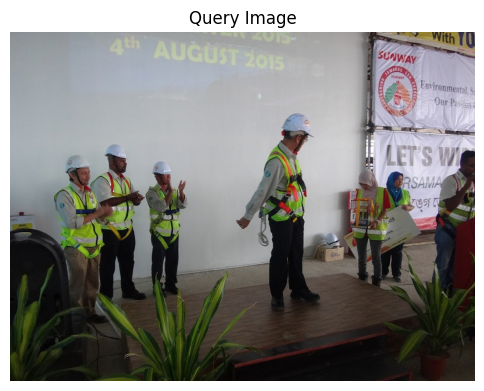

In [33]:
query_path = os.path.join(
    IMAGE_DIR,
    query_image_name
)

query_img = cv2.imread(query_path)

query_img = cv2.cvtColor(
    query_img,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(6,6))

plt.imshow(query_img)

plt.title("Query Image")

plt.axis("off")

plt.show()

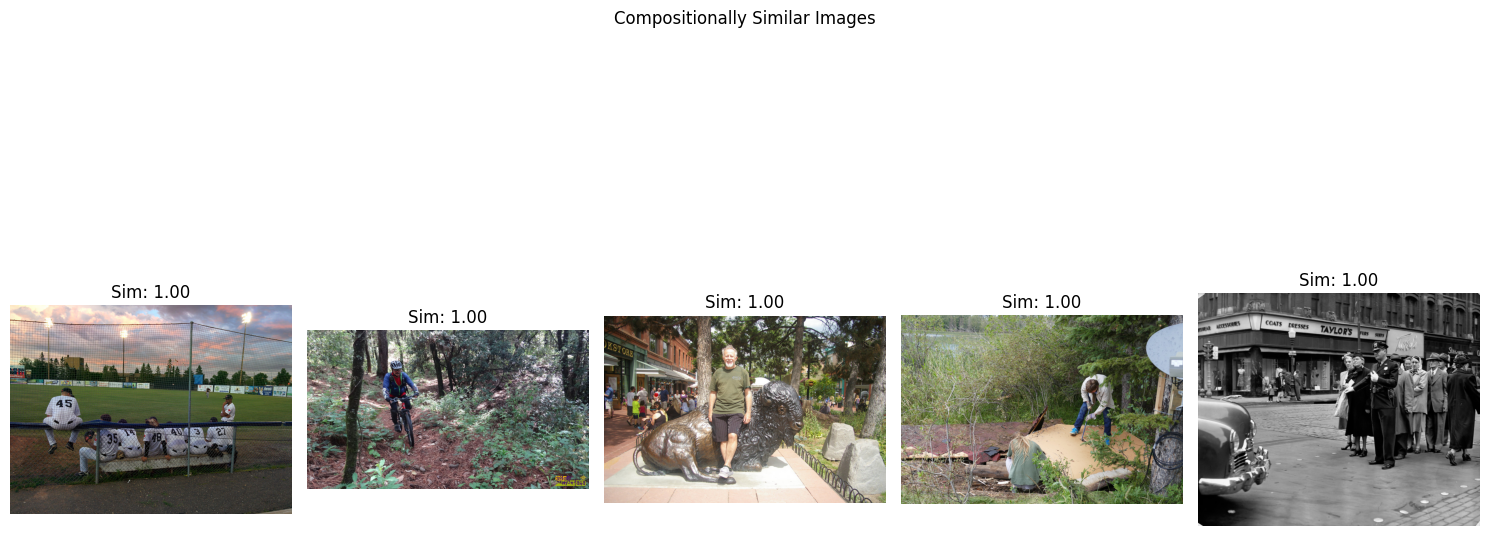

In [34]:
plt.figure(figsize=(15,8))

for i, idx in enumerate(top_indices):

    image_name = test_data[idx].image_name

    image_path = os.path.join(
        IMAGE_DIR,
        image_name
    )

    img = cv2.imread(image_path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    similarity_score = similarities[idx]

    plt.subplot(1,5,i+1)

    plt.imshow(img)

    plt.title(
        f"Sim: {similarity_score:.2f}"
    )

    plt.axis("off")

plt.suptitle(
    "Compositionally Similar Images"
)

plt.tight_layout()

plt.show()

In [35]:
import os

os.makedirs(
    "../artifacts/embeddings",
    exist_ok=True
)

os.makedirs(
    "../artifacts/clusters",
    exist_ok=True
)

os.makedirs(
    "../artifacts/visualizations",
    exist_ok=True
)

In [36]:
np.save(

    "../artifacts/embeddings/composition_embeddings.npy",

    embeddings
)

print("Embeddings saved")

Embeddings saved


In [37]:
np.save(

    "../artifacts/visualizations/tsne_embeddings.npy",

    embedding_2d
)

print("t-SNE saved")

t-SNE saved


In [38]:
np.save(

    "../artifacts/clusters/composition_clusters.npy",

    clusters
)

print("Clusters saved")

Clusters saved
